# EDA: Does Delivery Delay Affect Review Scores?

**Author:** Okunowo Oluwademilade David
**Date:** 2026-07-27

This notebook loads the cleaned master table produced by the cleaning
notebook and investigates whether late deliveries lead to lower
customer review scores.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load the cleaned master table

In [2]:
import pandas as pd

master = pd.read_csv("olist_master_cleaned.csv")

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors="coerce")

print(master[date_cols].dtypes)

orders_items = pd.read_csv("olist_order_items_dataset.csv", encoding="utf-8-sig")
products = pd.read_csv("olist_products_dataset.csv", encoding="utf-8-sig")
translation = pd.read_csv("product_category_name_translation.csv", encoding="utf-8-sig")

products["product_category_name"] = products["product_category_name"].fillna("unknown")
products_full = products.merge(translation, on="product_category_name", how="left")
products_full["product_category_name_english"] = products_full[
    "product_category_name_english"
].fillna("unknown")

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
review_creation_date             datetime64[ns]
dtype: object


## 2. Build analysis_df: only orders that were delivered and reviewed

In [3]:
analysis_df = master[
    master["order_delivered_customer_date"].notna() & master["review_score"].notna()
].copy()

## 3. Calculate delivery delay in days

In [4]:
analysis_df["delivery_delay_days"] = (
    analysis_df["order_delivered_customer_date"]
    - analysis_df["order_estimated_delivery_date"]
).dt.days

print(analysis_df["delivery_delay_days"].describe())

count    95830.000000
mean       -11.914067
std         10.113511
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


## 4. Bucket delay into early / on_time / late

In [5]:
def bucket_delay(days):
    if days < 0:
        return "early"
    elif days == 0:
        return "on_time"
    else:
        return "late"


analysis_df["delivery_bucket"] = analysis_df["delivery_delay_days"].apply(bucket_delay)

## 5. Compare average review score by delivery bucket

In [6]:
summary = (
    analysis_df.groupby("delivery_bucket")["review_score"]
    .agg(["mean", "count"])
    .round(2)
)
print(summary)

                 mean  count
delivery_bucket             
early            4.29  88168
late             2.27   6382
on_time          4.03   1280


## 6. Visualize average review score by delivery bucket

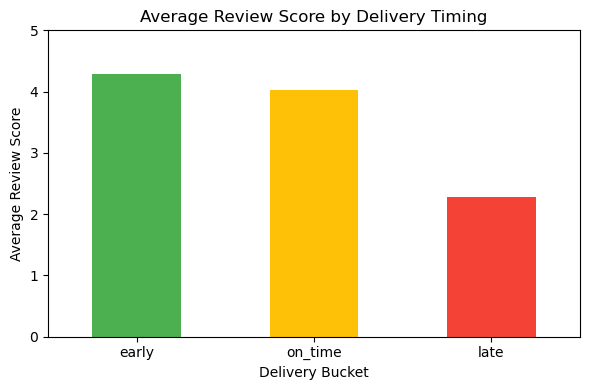

In [7]:
summary = (
    analysis_df.groupby("delivery_bucket")["review_score"]
    .mean()
    .reindex(["early", "on_time", "late"])
)

plt.figure(figsize=(6, 4))
summary.plot(kind="bar", color=["#4CAF50", "#FFC107", "#F44336"])
plt.title("Average Review Score by Delivery Timing")
plt.ylabel("Average Review Score")
plt.xlabel("Delivery Bucket")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## 7. Test statistical significance

In [8]:
early = analysis_df[analysis_df.delivery_bucket == "early"]["review_score"]
on_time = analysis_df[analysis_df.delivery_bucket == "on_time"]["review_score"]
late = analysis_df[analysis_df.delivery_bucket == "late"]["review_score"]
f_stat, p_val = stats.f_oneway(early, on_time, late)
print(f"ANOVA: F-statistic = {f_stat:.2f}, p-value = {p_val:.2e}")
t_stat, t_p = stats.ttest_ind(early, late, equal_var=False)
print(f"T-test (early vs late): t-statistic = {t_stat:.2f}, p-value = {t_p:.2e}")
corr, corr_p = stats.pearsonr(
    analysis_df["delivery_delay_days"], analysis_df["review_score"]
)
print(
    f"Pearson correlation (delay days vs review score): r = {corr:.3f}, p-value = {corr_p:.2e}"
)

ANOVA: F-statistic = 8724.86, p-value = 0.00e+00
T-test (early vs late): t-statistic = 100.91, p-value = 0.00e+00
Pearson correlation (delay days vs review score): r = -0.267, p-value = 0.00e+00


## 8. Does the delay effect vary by product category?

In [9]:
item_category = orders_items.merge(
    products_full[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left",
)
order_category = item_category.sort_values("order_item_id").drop_duplicates(
    subset="order_id", keep="first"
)[["order_id", "product_category_name_english"]]

analysis_df = analysis_df.merge(order_category, on="order_id", how="left")
cat_counts = analysis_df[analysis_df.delivery_bucket == "late"][
    "product_category_name_english"
].value_counts()
reliable_categories = cat_counts[cat_counts >= 50].index

subset = analysis_df[
    analysis_df["product_category_name_english"].isin(reliable_categories)
]

pivot = (
    subset.groupby(["product_category_name_english", "delivery_bucket"])["review_score"]
    .mean()
    .unstack()
)
pivot["drop_early_to_late"] = pivot["early"] - pivot["late"]
pivot = pivot.sort_values("drop_early_to_late", ascending=False)

print(pivot.round(2))

delivery_bucket                  early  late  on_time  drop_early_to_late
product_category_name_english                                            
toys                              4.38  2.12     3.84                2.26
baby                              4.30  2.09     4.10                2.22
sports_leisure                    4.38  2.17     4.19                2.21
fashion_bags_accessories          4.36  2.20     3.95                2.16
stationery                        4.45  2.32     3.81                2.14
pet_shop                          4.39  2.25     4.30                2.14
perfumery                         4.40  2.29     4.62                2.11
construction_tools_construction   4.28  2.17     4.31                2.11
cool_stuff                        4.35  2.25     3.97                2.10
watches_gifts                     4.28  2.20     3.84                2.08
unknown                           4.18  2.10     3.65                2.08
consoles_games                    4.32

## 10. Conclusion: category-level breakdown

Across the 22 product categories with a sufficient number of late deliveries, the decline in average review scores between early and late deliveries
was highly consistent, ranging from approximately 2.0 ro 2.3 points. No single category appeared to be significantly more or less affected by delivery
delays than others.

The Largest declines were observed in the Toys,Baby and Sports & Lesuire categories, where reviews scores dropped by more than 2.2 points. In contrast,
Health & Beauty and Garden Tools experienced the smallest declines, at around 2.0 points. However, these differences were relatively small compared 
with overall impact of late deliveries. Office_furniture also appears to have lower baseline satisfaction independent of delivery timing, worth a separate look.

**Takeaway:** The negative effect of delivery delays on customer satidfaction is consistent across product categories rather than being limited to a 
few specific types of products. This indicates that delivery reliability is a platform-wide driver of customer satisfaction. As a result, improving 
delivery performance acroos all categories is likley to have a greater impact on oerall review scores than focusing improvement efforts on individual
categories.
